# Multi-class topic classifier v1

Predict `topic` (10 classes) from `article_text`.

**Pipeline:** TF-IDF + multinomial Logistic Regression (no model-family selection in v1).

**Evaluation:**
- **Layer A** — always predict (argmax): macro F1 / macro OvR ROC-AUC on all holdout rows
- **Layer B** — confidence abstain: one global threshold on max-proba (primary) or top1−top2 margin (secondary); metrics on auto-routed subset only

Binary routing counterpart: [`ml_binary_v1.ipynb`](ml_binary_v1.ipynb).


## 1. Setup


In [81]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROC_ALPHA = 0.45


In [82]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    """Find data file whether the kernel cwd is project root or notebooks/."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )

DATA_PATH = resolve_data_path()
print("Loading:", DATA_PATH)


Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv


## 2. Load and label


In [84]:
df = pd.read_csv(DATA_PATH)
y = df["topic"]

print("shape:", df.shape)
print("nulls:", df[["article_text", "topic"]].isna().sum().to_dict())
print("\n# classes:", y.nunique())
print("\nlabel balance:")
print(y.value_counts())
print(y.value_counts(normalize=True).rename("fraction").round(3))
print("\nnote: smallest classes have n=10 → ~2 test rows after 80/20; metrics will be noisy.")


shape: (200, 12)
nulls: {'article_text': 0, 'topic': 0}

# classes: 10

label balance:
topic
cloud_computing             35
telecommunications          35
cybersecurity               25
consumer_electronics        20
enterprise_software         20
financial_services          20
healthcare                  15
retail_ecommerce            10
transportation_logistics    10
energy                      10
Name: count, dtype: int64
topic
cloud_computing             0.175
telecommunications          0.175
cybersecurity               0.125
consumer_electronics        0.100
enterprise_software         0.100
financial_services          0.100
healthcare                  0.075
retail_ecommerce            0.050
transportation_logistics    0.050
energy                      0.050
Name: fraction, dtype: float64

note: smallest classes have n=10 → ~2 test rows after 80/20; metrics will be noisy.


## 3. Stratified train / test split

Holdout is used **once** for the final Layer A report. All CV and tuning stay on train.


In [86]:
X = df["article_text"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("\ntrain class counts:")
print(y_train.value_counts().sort_index())
print("\ntest class counts:")
print(y_test.value_counts().sort_index())


train: 160  test: 40

train class counts:
topic
cloud_computing             28
consumer_electronics        16
cybersecurity               20
energy                       8
enterprise_software         16
financial_services          16
healthcare                  12
retail_ecommerce             8
telecommunications          28
transportation_logistics     8
Name: count, dtype: int64

test class counts:
topic
cloud_computing             7
consumer_electronics        4
cybersecurity               5
energy                      2
enterprise_software         4
financial_services          4
healthcare                  3
retail_ecommerce            2
telecommunications          7
transportation_logistics    2
Name: count, dtype: int64


## 4. Pipeline + hyperparameter tuning (F1-macro)

Single model family: TF-IDF → multinomial LogisticRegression. Grid search with stratified 5-fold CV on train only. Scoring: **`f1_macro`**.


In [88]:
pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_features": [5000, 10000, None],
    "clf__C": [0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
CLASS_NAMES = list(best_model.named_steps["clf"].classes_)

print("best CV F1-macro:", round(search.best_score_, 4))
print("best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print("classes:", CLASS_NAMES)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
best CV F1-macro: 0.435
best params:
  clf__C: 10.0
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)
classes: ['cloud_computing', 'consumer_electronics', 'cybersecurity', 'energy', 'enterprise_software', 'financial_services', 'healthcare', 'retail_ecommerce', 'telecommunications', 'transportation_logistics']


### GridSearchCV results (visualization)

Post-hoc view of CV F1-macro across the grid. Useful to see winners and fold noise; does not change the selected `best_model`.


top 10 configs by mean CV F1-macro:


,mean_test_score,std_test_score,param_label
0,0.434957,0.080212,"C=10.0, max_features=5000, min_df=1, ngram_ran..."
1,0.434957,0.080212,"C=10.0, max_features=None, min_df=1, ngram_ran..."
2,0.434957,0.080212,"C=10.0, max_features=10000, min_df=1, ngram_ra..."
3,0.372040,0.081721,"C=10.0, max_features=None, min_df=2, ngram_ran..."
4,0.372040,0.081721,"C=10.0, max_features=10000, min_df=2, ngram_ra..."
5,0.372040,0.081721,"C=10.0, max_features=5000, min_df=2, ngram_ran..."
6,0.361209,0.066543,"C=10.0, max_features=None, min_df=1, ngram_ran..."
7,0.361209,0.066543,"C=10.0, max_features=10000, min_df=1, ngram_ra..."
8,0.361209,0.066543,"C=10.0, max_features=5000, min_df=1, ngram_ran..."
9,0.293786,0.066008,"C=1.0, max_features=10000, min_df=1, ngram_ran..."


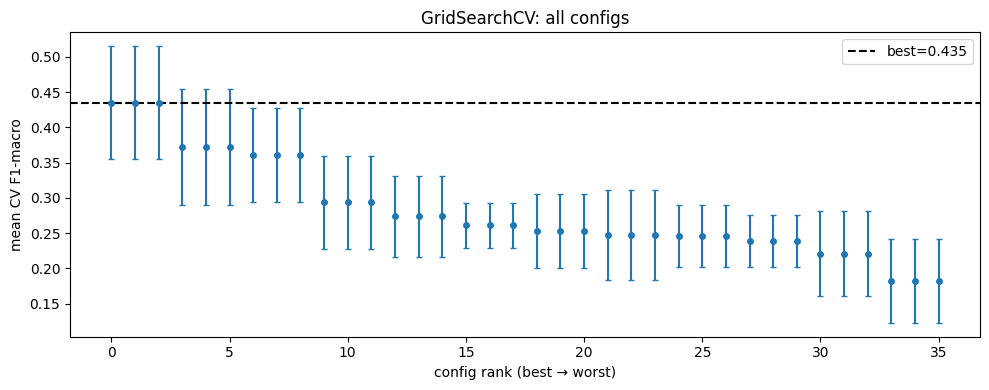

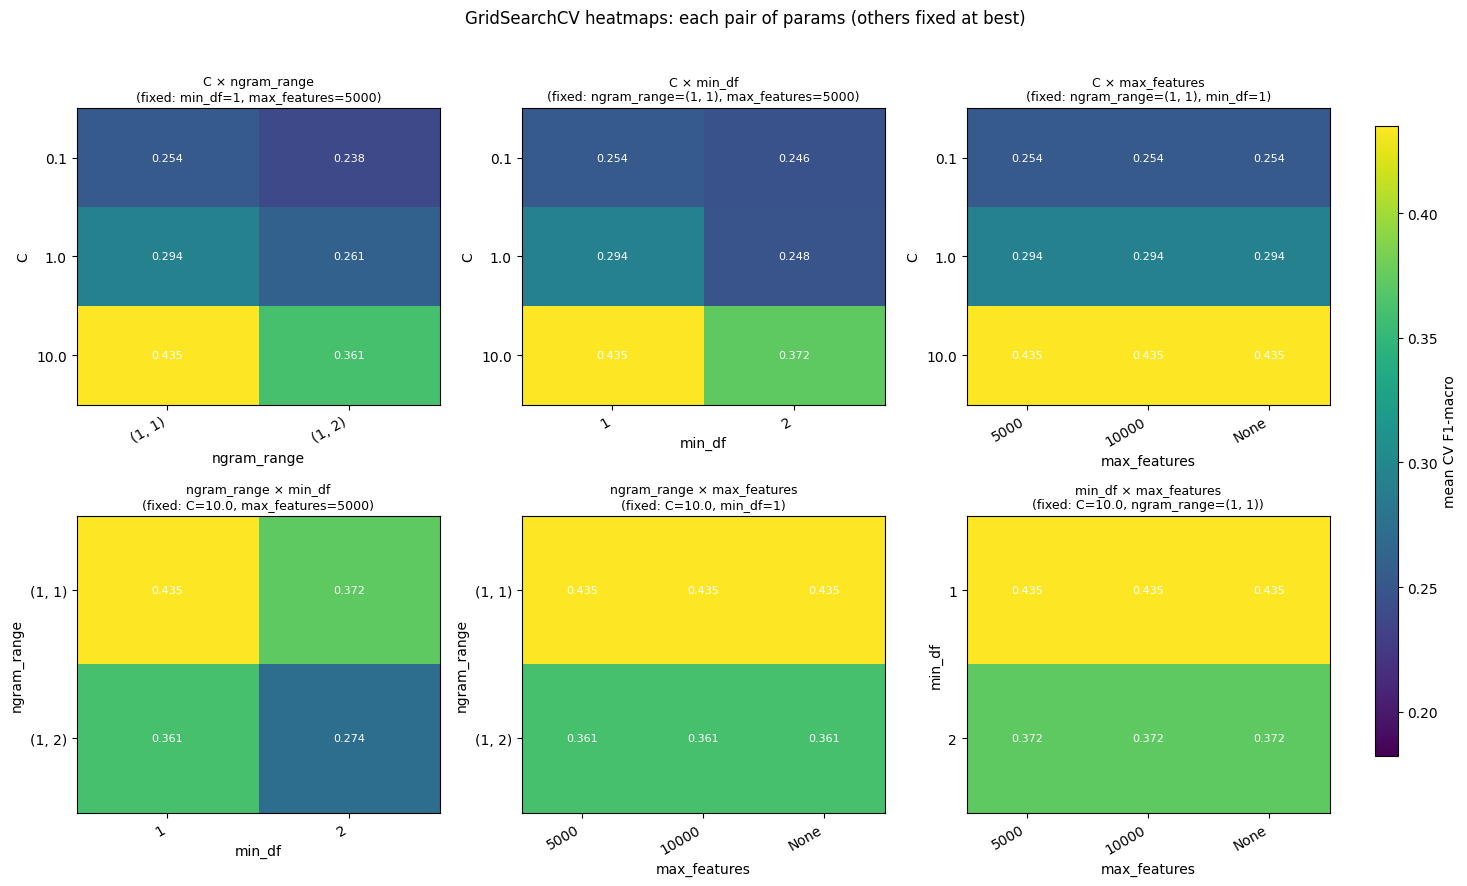

In [90]:
from itertools import combinations

PARAM_KEYS = [
    "clf__C",
    "tfidf__ngram_range",
    "tfidf__min_df",
    "tfidf__max_features",
]

cv_results = pd.DataFrame(search.cv_results_).sort_values(
    "mean_test_score", ascending=False
).reset_index(drop=True)

cv_results["param_label"] = cv_results["params"].apply(
    lambda d: ", ".join(f"{k.split('__')[-1]}={v}" for k, v in d.items())
)

print("top 10 configs by mean CV F1-macro:")
display(
    cv_results.loc[:9, ["mean_test_score", "std_test_score", "param_label"]]
)

# --- Figure 1: ranked CV scores ---
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.errorbar(
    cv_results.index,
    cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
    fmt="o",
    markersize=4,
    capsize=2,
)
ax1.axhline(
    search.best_score_, color="black", linestyle="--", label=f"best={search.best_score_:.3f}"
)
ax1.set_xlabel("config rank (best → worst)")
ax1.set_ylabel("mean CV F1-macro")
ax1.set_title("GridSearchCV: all configs")
ax1.legend()
fig1.tight_layout()
plt.show()

# --- Figure 2: 6 heatmaps (C(4,2) param pairs; others fixed at best) ---
best = search.best_params_


def _short(name):
    return name.split("__")[-1]


def _fmt(v):
    return "None" if v is None else str(v)


def _grid_order(key):
    """Preserve grid order; read values from params dict (handles None cleanly)."""
    vals = []
    for p in search.cv_results_["params"]:
        v = p[key]
        if v not in vals:
            vals.append(v)
    return vals


def _filter_fixed(df, fixed: dict):
    return df[df["params"].apply(lambda p: all(p.get(k) == v for k, v in fixed.items()))]


fig2, axes = plt.subplots(2, 3, figsize=(15, 9))
pair_list = list(combinations(PARAM_KEYS, 2))
vmin = cv_results["mean_test_score"].min()
vmax = cv_results["mean_test_score"].max()

for ax, (row_key, col_key) in zip(axes.ravel(), pair_list):
    fixed_keys = [k for k in PARAM_KEYS if k not in (row_key, col_key)]
    fixed = {k: best[k] for k in fixed_keys}
    sub = _filter_fixed(cv_results, fixed).copy()

    row_order = _grid_order(row_key)
    col_order = _grid_order(col_key)
    sub["_row"] = sub["params"].apply(lambda p: _fmt(p[row_key]))
    sub["_col"] = sub["params"].apply(lambda p: _fmt(p[col_key]))
    pivot = sub.pivot_table(
        index="_row",
        columns="_col",
        values="mean_test_score",
        aggfunc="first",
    ).reindex(
        index=[_fmt(v) for v in row_order],
        columns=[_fmt(v) for v in col_order],
    )

    im = ax.imshow(
        pivot.values.astype(float),
        aspect="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(list(pivot.columns), rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(list(pivot.index))
    ax.set_xlabel(_short(col_key))
    ax.set_ylabel(_short(row_key))
    fixed_txt = ", ".join(f"{_short(k)}={_fmt(best[k])}" for k in fixed_keys)
    ax.set_title(f"{_short(row_key)} × {_short(col_key)}\n(fixed: {fixed_txt})", fontsize=9)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if val == val:
                ax.text(j, i, f"{float(val):.3f}", ha="center", va="center", color="white", fontsize=8)

fig2.suptitle("GridSearchCV heatmaps: each pair of params (others fixed at best)")
fig2.tight_layout(rect=[0, 0, 0.90, 0.96])
cax = fig2.add_axes([0.92, 0.15, 0.015, 0.7])
fig2.colorbar(im, cax=cax, label="mean CV F1-macro")
plt.show()


## 5. Layer A — always predict (model quality)

Every test row gets a topic via argmax. Layer B abstain is separate (next section).


=== Layer A — argmax (always predict) ===
                          precision    recall  f1-score   support

         cloud_computing       0.44      0.57      0.50         7
    consumer_electronics       0.67      0.50      0.57         4
           cybersecurity       1.00      0.40      0.57         5
                  energy       0.50      0.50      0.50         2
     enterprise_software       1.00      0.75      0.86         4
      financial_services       0.33      0.50      0.40         4
              healthcare       0.50      0.33      0.40         3
        retail_ecommerce       0.20      0.50      0.29         2
      telecommunications       1.00      0.86      0.92         7
transportation_logistics       0.00      0.00      0.00         2

                accuracy                           0.55        40
               macro avg       0.56      0.49      0.50        40
            weighted avg       0.65      0.55      0.57        40

accuracy   : 0.55
F1 macro   : 

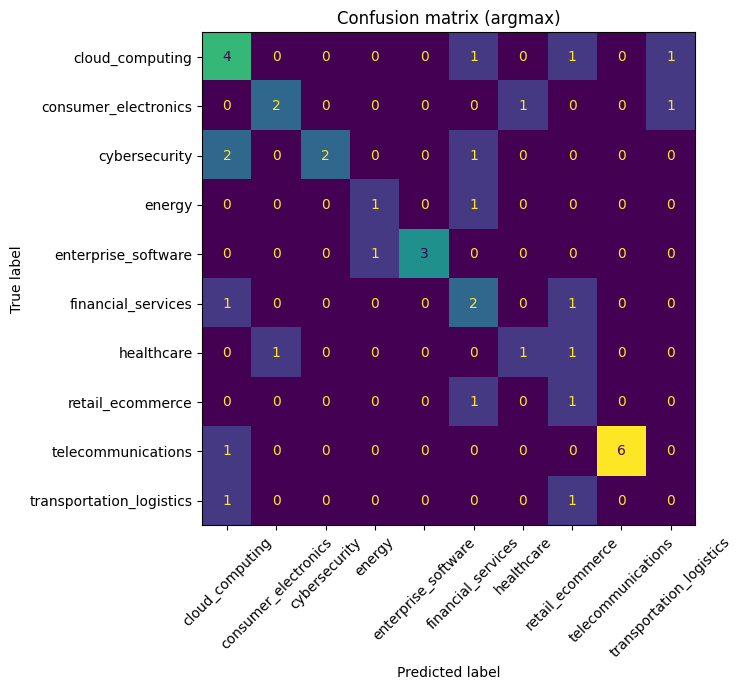

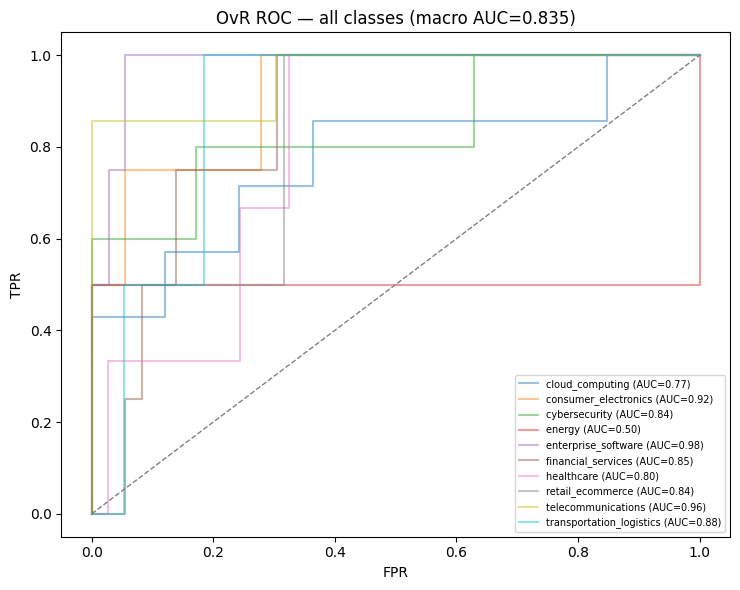

In [92]:
print("=== Layer A — argmax (always predict) ===")

proba_test = best_model.predict_proba(X_test)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, labels=CLASS_NAMES, zero_division=0))
print("accuracy   :", round(accuracy_score(y_test, y_pred), 4))
print("F1 macro   :", round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4))
print("F1 weighted:", round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4))
print(
    "ROC-AUC macro (OvR):",
    round(roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro", labels=CLASS_NAMES), 4),
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=CLASS_NAMES),
    display_labels=CLASS_NAMES,
).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion matrix (argmax)")
plt.tight_layout()
plt.show()

# Overlay all OvR ROC curves
y_test_bin = label_binarize(y_test, classes=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_test[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], proba_test[:, i])
    ax.plot(fpr, tpr, alpha=ROC_ALPHA, label=f"{cls} (AUC={auc_i:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
macro_auc = roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro", labels=CLASS_NAMES)
ax.set_title(f"OvR ROC — all classes (macro AUC={macro_auc:.3f})")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


### Better than chance? — baseline comparison

Compare the fitted model to simple **label-only** baselines that **ignore `article_text`**:

| name | what it does |
|---|---|
| **TF-IDF + LR** | learns from article text |
| **Always majority class** | every row → most common **train** topic |
| **Random w/ train rates** | each row drawn from **train** topic frequencies |
| **Uniform random** | each row uniform over classes; ignores train mix |

If TF-IDF + LR beats these on the **same test set**, the model is using the text (not just label prevalence).


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
model,,,,,
TF-IDF + LR (tuned),0.550,0.5644,0.4912,0.5009,0.8347
Always majority class,0.175,0.0175,0.1000,0.0298,0.5000
Random w/ train rates,0.075,0.0625,0.0543,0.0578,0.4743
Uniform random,0.175,0.2033,0.1629,0.1622,0.5000



F1-macro lift vs best label-only baseline: +0.3387  (model=0.5009, best_baseline=0.1622)


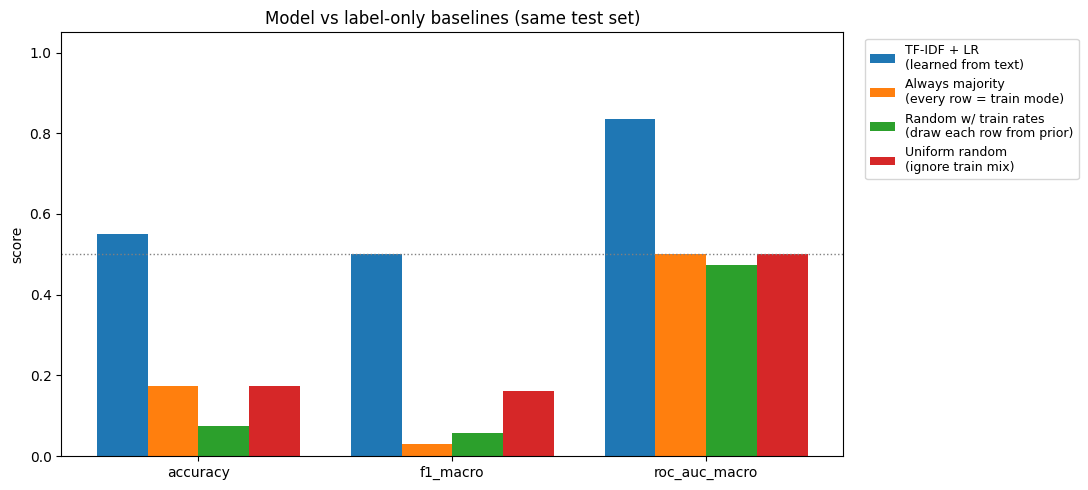

In [94]:
from sklearn.dummy import DummyClassifier


def eval_multi(name, y_true, y_hat, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "roc_auc_macro": roc_auc_score(
            y_true, y_score, multi_class="ovr", average="macro", labels=CLASS_NAMES
        ),
    }


MODEL_NAME = "TF-IDF + LR (tuned)"
baseline_rows = [
    eval_multi(MODEL_NAME, y_test, y_pred, proba_test),
]

dummy_specs = [
    (
        "Always majority class",
        "most_frequent",
        "Always majority\n(every row = train mode)",
    ),
    (
        "Random w/ train rates",
        "stratified",
        "Random w/ train rates\n(draw each row from prior)",
    ),
    (
        "Uniform random",
        "uniform",
        "Uniform random\n(ignore train mix)",
    ),
]

legend_labels = {MODEL_NAME: "TF-IDF + LR\n(learned from text)"}
for name, strategy, legend in dummy_specs:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)  # X ignored; learns label prior only
    y_hat = dummy.predict(X_test)
    y_score = dummy.predict_proba(X_test)
    dummy_classes = list(dummy.classes_)
    aligned = np.zeros((len(y_hat), len(CLASS_NAMES)))
    for j, cls in enumerate(CLASS_NAMES):
        if cls in dummy_classes:
            aligned[:, j] = y_score[:, dummy_classes.index(cls)]
    baseline_rows.append(eval_multi(name, y_test, y_hat, aligned))
    legend_labels[name] = legend

baseline_cmp = pd.DataFrame(baseline_rows).set_index("model")
display(baseline_cmp.round(4))

best_dummy_f1 = baseline_cmp.drop(index=MODEL_NAME)["f1_macro"].max()
model_f1 = baseline_cmp.loc[MODEL_NAME, "f1_macro"]
print(
    f"\nF1-macro lift vs best label-only baseline: {model_f1 - best_dummy_f1:+.4f}  "
    f"(model={model_f1:.4f}, best_baseline={best_dummy_f1:.4f})"
)

plot_metrics = ["accuracy", "f1_macro", "roc_auc_macro"]
plot_df = baseline_cmp[plot_metrics]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_metrics))
width = 0.2
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=legend_labels[model_name])
ax.set_xticks(x + width * (len(plot_df) - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Model vs label-only baselines (same test set)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


## 6. Layer B — confidence abstain (multi-class)

Unlike binary routing (a band around `P(target)=0.5`), multi-class already picks a label via argmax. Abstain asks whether that pick is confident enough.

**Confidence scores**
- **max-proba (primary / operating policy):** `s = max_k P(k)`
- **margin (diagnostic only):** `s = P_(1) − P_(2)`

**Decision rule (one global threshold τ)**
```
if s >= τ  → auto-label with argmax topic
else       → abstain (no auto-label)
```

Layer B metrics use **only** auto-routed rows. Coverage / abstain rate are reported separately.

**Choosing τ:** because the fitted train set is nearly separable (train macro-F1 ≈ 1), we do **not** pick τ from in-sample train probabilities. Instead:

1. Build **out-of-fold** `predict_proba` on the training rows (5-fold stratified, cloning the selected pipeline)
2. Sweep τ on those OOF scores
3. Pick the τ that maximizes **OOF routed macro-F1** subject to **OOF coverage ≥ 70%** (fallback: best OOF F1 if no τ meets the floor)
4. Freeze that τ, then score **once** on the held-out test set with the full `best_model`

**Why max-proba wins here:** with 10 classes, top1−top2 margins stay small even on correct rows, so any τ that improves OOF F1 usually destroys coverage (fallback below the 70% floor). Max-proba has a wider usable range and can meet the coverage floor while still lifting routed macro-F1 on test. **Ship Layer B on max-proba;** keep margin as a diagnostic comparison, not the production abstain score.


In [96]:
# --- Confidence scores + OOF tau selection (train only) ---
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

classes_ = np.asarray(best_model.named_steps["clf"].classes_)
proba_test = best_model.predict_proba(X_test)  # ensure available if cells re-run out of order


def max_proba_scores(proba: np.ndarray) -> np.ndarray:
    return proba.max(axis=1)


def margin_top2_scores(proba: np.ndarray) -> np.ndarray:
    part = np.partition(proba, -2, axis=1)
    return part[:, -1] - part[:, -2]


def argmax_labels(proba: np.ndarray) -> np.ndarray:
    return classes_[proba.argmax(axis=1)]


def routed_metrics(y_true, proba: np.ndarray, tau: float, score_fn) -> dict:
    scores = score_fn(proba)
    mask = scores >= tau
    n_routed = int(mask.sum())
    if n_routed == 0:
        return {
            "coverage": 0.0,
            "abstain_rate": 1.0,
            "n_routed": 0,
            "f1_macro": np.nan,
            "accuracy": np.nan,
        }
    y_hat = argmax_labels(proba)
    y_true_arr = np.asarray(y_true)
    return {
        "coverage": float(mask.mean()),
        "abstain_rate": float((~mask).mean()),
        "n_routed": n_routed,
        "f1_macro": float(
            f1_score(
                y_true_arr[mask],
                y_hat[mask],
                average="macro",
                labels=CLASS_NAMES,
                zero_division=0,
            )
        ),
        "accuracy": float(accuracy_score(y_true_arr[mask], y_hat[mask])),
    }


COVER_TARGET = 0.70
TAU_GRID = np.linspace(0.15, 0.95, 81)
N_OOF_SPLITS = 5

# Out-of-fold probabilities on train (avoids saturated in-sample train F1)
X_train_oof = X_train.reset_index(drop=True)
y_train_oof = y_train.reset_index(drop=True)
oof_proba = np.zeros((len(X_train_oof), len(classes_)), dtype=float)

skf = StratifiedKFold(n_splits=N_OOF_SPLITS, shuffle=True, random_state=RANDOM_STATE)
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_oof, y_train_oof), start=1):
    fold_model = clone(best_model)
    fold_model.fit(X_train_oof.iloc[tr_idx], y_train_oof.iloc[tr_idx])
    # Align columns to classes_ of the full model
    fold_classes = list(fold_model.named_steps["clf"].classes_)
    fold_proba = fold_model.predict_proba(X_train_oof.iloc[va_idx])
    col_idx = [fold_classes.index(c) for c in classes_]
    oof_proba[va_idx] = fold_proba[:, col_idx]
    print(f"OOF fold {fold}/{N_OOF_SPLITS}: val n={len(va_idx)}")


def select_tau(y_true, proba: np.ndarray, score_fn, cover_target: float = COVER_TARGET):
    rows = []
    for tau in TAU_GRID:
        m = routed_metrics(y_true, proba, float(tau), score_fn)
        rows.append({"tau": float(tau), **m})
    sweep = pd.DataFrame(rows)
    eligible = sweep[sweep["coverage"] >= cover_target].copy()
    if len(eligible):
        # max OOF routed F1, tie-break toward more selective (larger) tau
        best = eligible.sort_values(["f1_macro", "tau"], ascending=[False, False]).iloc[0]
        rule = f"max OOF routed F1 | coverage>={cover_target:.0%}"
    else:
        best = sweep.sort_values(["f1_macro", "tau"], ascending=[False, False]).iloc[0]
        rule = "fallback: max OOF routed F1 (no tau met coverage floor)"
    return float(best["tau"]), sweep, rule


tau_maxp, sweep_maxp, rule_maxp = select_tau(y_train_oof, oof_proba, max_proba_scores)
tau_margin, sweep_margin, rule_margin = select_tau(y_train_oof, oof_proba, margin_top2_scores)

print()
print("max-proba OOF selection:", rule_maxp)
print(f"  tau* = {tau_maxp:.3f}")
print(
    sweep_maxp.iloc[(sweep_maxp["tau"] - tau_maxp).abs().to_numpy().argmin()][
        ["tau", "coverage", "f1_macro", "accuracy", "n_routed"]
    ]
)
print()
print("margin OOF selection:", rule_margin)
print(f"  tau* = {tau_margin:.3f}")
print(
    sweep_margin.iloc[(sweep_margin["tau"] - tau_margin).abs().to_numpy().argmin()][
        ["tau", "coverage", "f1_macro", "accuracy", "n_routed"]
    ]
)


OOF fold 1/5: val n=32
OOF fold 2/5: val n=32
OOF fold 3/5: val n=32
OOF fold 4/5: val n=32
OOF fold 5/5: val n=32

max-proba OOF selection: max OOF routed F1 | coverage>=70%
  tau* = 0.260
tau           0.260000
coverage      0.718750
f1_macro      0.500243
accuracy      0.556522
n_routed    115.000000
Name: 11, dtype: float64

margin OOF selection: fallback: max OOF routed F1 (no tau met coverage floor)
  tau* = 0.360
tau          0.360000
coverage     0.175000
f1_macro     0.707143
accuracy     0.892857
n_routed    28.000000
Name: 21, dtype: float64


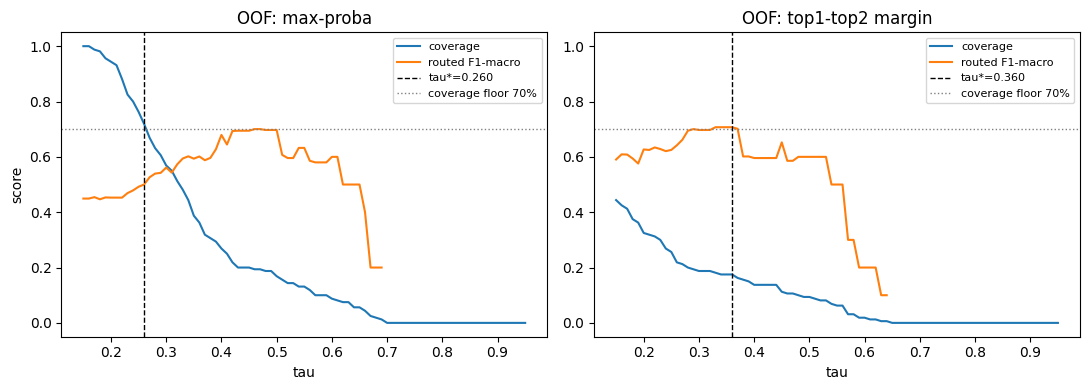

In [97]:
# OOF tradeoff curves (selection only — do not use test here)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, sweep, tau_star, title in [
    (axes[0], sweep_maxp, tau_maxp, "max-proba"),
    (axes[1], sweep_margin, tau_margin, "top1-top2 margin"),
]:
    ax.plot(sweep["tau"], sweep["coverage"], label="coverage", color="C0")
    ax.plot(sweep["tau"], sweep["f1_macro"], label="routed F1-macro", color="C1")
    ax.axvline(tau_star, color="black", linestyle="--", linewidth=1, label=f"tau*={tau_star:.3f}")
    ax.axhline(COVER_TARGET, color="gray", linestyle=":", linewidth=1, label=f"coverage floor {COVER_TARGET:.0%}")
    ax.set_xlabel("tau")
    ax.set_title(f"OOF: {title}")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("score")
plt.tight_layout()
plt.show()


In [ ]:
# Freeze OOF-selected tau*; evaluate once on test
layer_a_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
layer_a_acc = accuracy_score(y_test, y_pred)

test_maxp = routed_metrics(y_test, proba_test, tau_maxp, max_proba_scores)
test_margin = routed_metrics(y_test, proba_test, tau_margin, margin_top2_scores)

scores_test_maxp = max_proba_scores(proba_test)
routed_mask_maxp = scores_test_maxp >= tau_maxp
abstain_mask_maxp = ~routed_mask_maxp
y_hat_test = argmax_labels(proba_test)

print("=== Layer B @ max-proba (primary) ===")
print(f"tau* (OOF): {tau_maxp:.3f}")
print(f"coverage:     {test_maxp['coverage']:.1%}  ({test_maxp['n_routed']}/{len(y_test)})")
print(f"abstain rate: {test_maxp['abstain_rate']:.1%}  ({abstain_mask_maxp.sum()}/{len(y_test)})")
if test_maxp["n_routed"]:
    print()
    print(classification_report(
        np.asarray(y_test)[routed_mask_maxp],
        y_hat_test[routed_mask_maxp],
        labels=CLASS_NAMES,
        zero_division=0,
    ))
else:
    print("No rows auto-routed at this tau.")

print("=== Layer B @ margin (secondary) ===")
print(f"tau* (OOF): {tau_margin:.3f}")
print(f"coverage:     {test_margin['coverage']:.1%}  ({test_margin['n_routed']}/{len(y_test)})")
print(f"abstain rate: {test_margin['abstain_rate']:.1%}")

margin_met_floor = "coverage>=" in rule_margin and "fallback" not in rule_margin
summary_b = pd.DataFrame(
    [
        {
            "mode": "Layer A always-predict (argmax)",
            "score": "—",
            "role": "baseline",
            "tau": np.nan,
            "coverage": 1.0,
            "f1_macro": layer_a_f1,
            "accuracy": layer_a_acc,
        },
        {
            "mode": "Layer B abstain (max-proba)",
            "score": "max-proba",
            "role": "operating policy",
            "tau": tau_maxp,
            "coverage": test_maxp["coverage"],
            "f1_macro": test_maxp["f1_macro"],
            "accuracy": test_maxp["accuracy"],
        },
        {
            "mode": "Layer B abstain (margin)",
            "score": "top1-top2",
            "role": "diagnostic" if not margin_met_floor else "secondary",
            "tau": tau_margin,
            "coverage": test_margin["coverage"],
            "f1_macro": test_margin["f1_macro"],
            "accuracy": test_margin["accuracy"],
        },
    ]
)
display(summary_b.round(4))
if not margin_met_floor:
    print("Note: margin did not meet the OOF coverage floor — treat as diagnostic only; use max-proba for Layer B.")


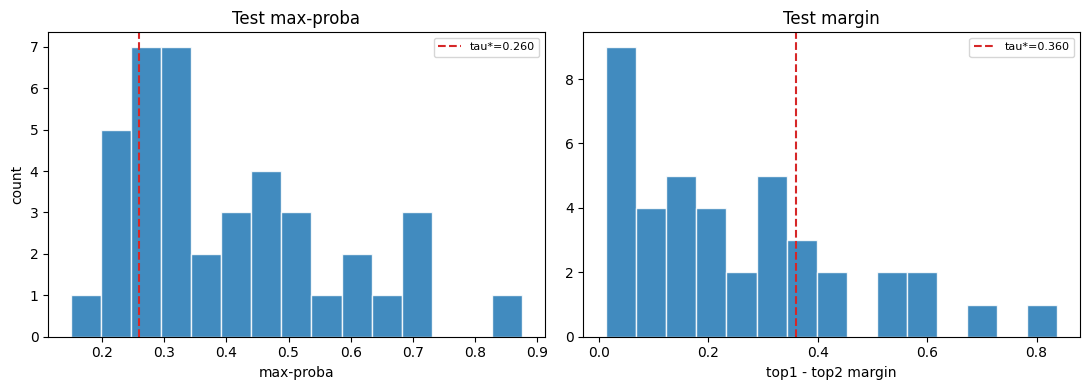

In [99]:
# Test score distributions with selected thresholds
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(max_proba_scores(proba_test), bins=15, edgecolor="white", alpha=0.85)
axes[0].axvline(tau_maxp, color="C3", linestyle="--", label=f"tau*={tau_maxp:.3f}")
axes[0].set_xlabel("max-proba")
axes[0].set_ylabel("count")
axes[0].set_title("Test max-proba")
axes[0].legend(fontsize=8)

axes[1].hist(margin_top2_scores(proba_test), bins=15, edgecolor="white", alpha=0.85, color="C0")
axes[1].axvline(tau_margin, color="C3", linestyle="--", label=f"tau*={tau_margin:.3f}")
axes[1].set_xlabel("top1 - top2 margin")
axes[1].set_title("Test margin")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [100]:
# Abstain slice (primary: max-proba policy)
if abstain_mask_maxp.any():
    abstain_df = pd.DataFrame({
        "y_true": np.asarray(y_test)[abstain_mask_maxp],
        "y_pred_argmax": y_hat_test[abstain_mask_maxp],
        "max_proba": scores_test_maxp[abstain_mask_maxp],
        "margin": margin_top2_scores(proba_test)[abstain_mask_maxp],
    })
    print("abstain count:", len(abstain_df))
    print("true-topic mix among abstains:")
    print(abstain_df["y_true"].value_counts())
    print()
    print("mean max-proba among abstains:", round(abstain_df["max_proba"].mean(), 4))
    print("mean margin among abstains:   ", round(abstain_df["margin"].mean(), 4))
    display(abstain_df.sort_values("max_proba").head(12))
else:
    print("No abstains at the selected max-proba tau*.")


abstain count: 9
true-topic mix among abstains:
y_true
cybersecurity          3
cloud_computing        2
healthcare             1
enterprise_software    1
financial_services     1
telecommunications     1
Name: count, dtype: int64

mean max-proba among abstains: 0.2256
mean margin among abstains:    0.0357


,y_true,y_pred_argmax,max_proba,margin
4,enterprise_software,energy,0.149774,0.013617
2,healthcare,healthcare,0.200212,0.060447
1,cybersecurity,cloud_computing,0.216556,0.069779
6,financial_services,retail_ecommerce,0.234132,0.041040
5,cybersecurity,financial_services,0.234416,0.020943
0,cloud_computing,cloud_computing,0.240359,0.041134
8,cloud_computing,transportation_logistics,0.250691,0.037788
7,telecommunications,cloud_computing,0.251372,0.016336
3,cybersecurity,cloud_computing,0.252461,0.020520


### Layer B improvement analysis (max-proba policy)

Side-by-side view of **Layer A (always predict)** vs **Layer B (auto-route only when `max-proba ≥ τ*`)**.

Focus question: of the mistakes Layer A would make on the holdout set, how many are **held for review** by abstain instead of being emitted as wrong labels?

The Layer A confusion matrix annotates off-diagonal cells with `(k saved)` and an orange outline when abstain catches ≥1 of those mistakes. Those cells disappear from the Layer B (routed-only) matrix.


=== Error triage (Layer A mistakes vs Layer B abstain) ===
Layer A mistakes on test:     18/40
  saved for review (abstain): 7/18  (38.9%)
  still auto-routed wrong:    11/18  (61.1%)
Correct rows held back:       2/22  (abstain cost on true positives)
Net: avoid 7 emitted mistakes; pay 2 extra manual reviews on rows Layer A had right.


,mode,n_scored,coverage,accuracy,f1_macro,f1_weighted,n_mistakes_emitted
0,Layer A always-predict,40,1.000,0.5500,0.5009,0.5726,18
1,Layer B routed (max-proba ≥ 0.260),31,0.775,0.6452,0.5671,0.6382,11


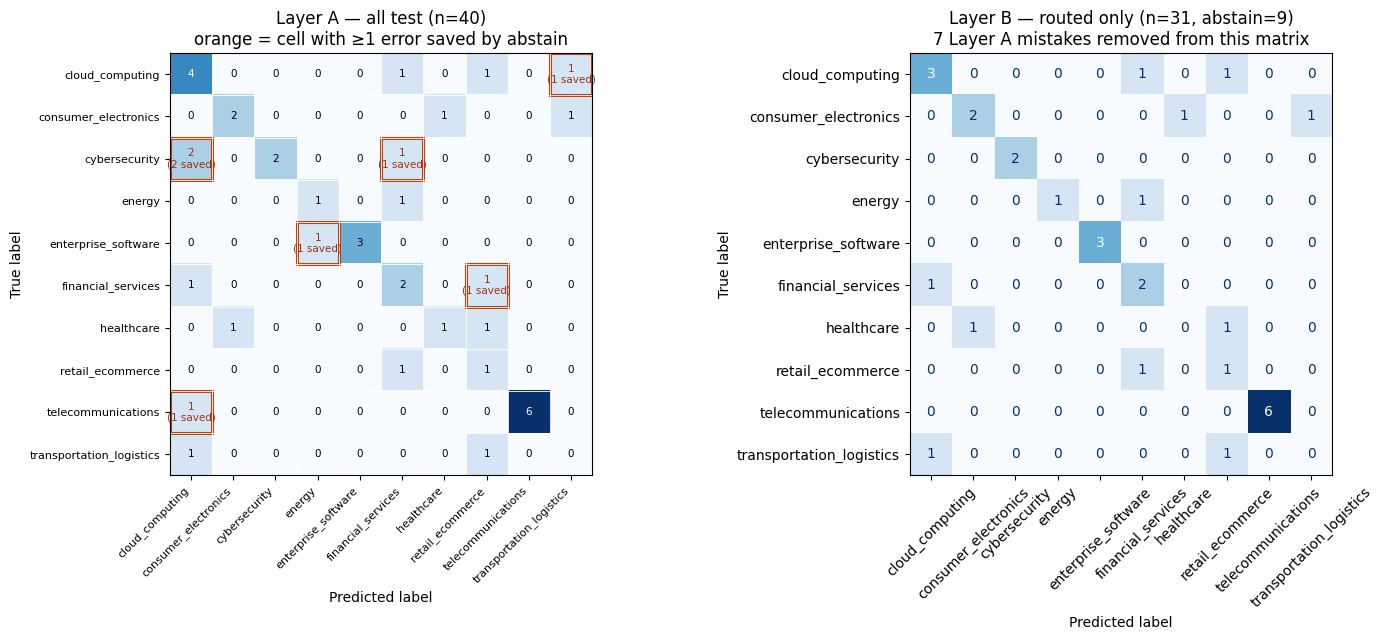

Reading the left matrix: off-diagonal count is total Layer A mistakes in that cell; "(k saved)" is how many of those are abstained under Layer B (orange outline).
Disposition of every Layer A mistake:


,y_true,y_pred_layer_a,max_proba,layer_b
6,enterprise_software,energy,0.149774,abstain (saved for review)
3,cybersecurity,cloud_computing,0.216556,abstain (saved for review)
15,financial_services,retail_ecommerce,0.234132,abstain (saved for review)
9,cybersecurity,financial_services,0.234416,abstain (saved for review)
17,cloud_computing,transportation_logistics,0.250691,abstain (saved for review)
16,telecommunications,cloud_computing,0.251372,abstain (saved for review)
5,cybersecurity,cloud_computing,0.252461,abstain (saved for review)
2,transportation_logistics,retail_ecommerce,0.278883,still routed (mistake)
10,transportation_logistics,cloud_computing,0.291272,still routed (mistake)
1,financial_services,cloud_computing,0.326892,still routed (mistake)


layer_b
still routed (mistake)        11
abstain (saved for review)     7
Name: count, dtype: int64


In [130]:
# Side-by-side: Layer A (all rows) vs Layer B (routed subset) — max-proba policy
y_true_arr = np.asarray(y_test)
y_a = np.asarray(y_pred)  # Layer A argmax on all test rows

a_correct = y_a == y_true_arr
a_error = ~a_correct

errors_saved = a_error & abstain_mask_maxp          # Layer A mistake → abstain (review)
errors_still_routed = a_error & routed_mask_maxp    # Layer A mistake → still auto-routed
correct_held_back = a_correct & abstain_mask_maxp   # Layer A correct → abstain (coverage cost)
correct_routed = a_correct & routed_mask_maxp

n_test = len(y_true_arr)
n_a_err = int(a_error.sum())
n_saved = int(errors_saved.sum())
n_still = int(errors_still_routed.sum())
n_held = int(correct_held_back.sum())

print("=== Error triage (Layer A mistakes vs Layer B abstain) ===")
print(f"Layer A mistakes on test:     {n_a_err}/{n_test}")
print(f"  saved for review (abstain): {n_saved}/{n_a_err}  ({(n_saved / n_a_err) if n_a_err else float('nan'):.1%})")
print(f"  still auto-routed wrong:    {n_still}/{n_a_err}  ({(n_still / n_a_err) if n_a_err else float('nan'):.1%})")
print(f"Correct rows held back:       {n_held}/{int(a_correct.sum())}  (abstain cost on true positives)")
print(f"Net: avoid {n_saved} emitted mistakes; pay {n_held} extra manual reviews on rows Layer A had right.")

improve = pd.DataFrame(
    [
        {
            "mode": "Layer A always-predict",
            "n_scored": n_test,
            "coverage": 1.0,
            "accuracy": accuracy_score(y_true_arr, y_a),
            "f1_macro": f1_score(y_true_arr, y_a, average="macro", labels=CLASS_NAMES, zero_division=0),
            "f1_weighted": f1_score(y_true_arr, y_a, average="weighted", labels=CLASS_NAMES, zero_division=0),
            "n_mistakes_emitted": n_a_err,
        },
        {
            "mode": f"Layer B routed (max-proba ≥ {tau_maxp:.3f})",
            "n_scored": int(routed_mask_maxp.sum()),
            "coverage": float(routed_mask_maxp.mean()),
            "accuracy": accuracy_score(y_true_arr[routed_mask_maxp], y_a[routed_mask_maxp]) if routed_mask_maxp.any() else np.nan,
            "f1_macro": f1_score(
                y_true_arr[routed_mask_maxp],
                y_a[routed_mask_maxp],
                average="macro",
                labels=CLASS_NAMES,
                zero_division=0,
            ) if routed_mask_maxp.any() else np.nan,
            "f1_weighted": f1_score(
                y_true_arr[routed_mask_maxp],
                y_a[routed_mask_maxp],
                average="weighted",
                labels=CLASS_NAMES,
                zero_division=0,
            ) if routed_mask_maxp.any() else np.nan,
            "n_mistakes_emitted": n_still,
        },
    ]
)
display(improve.round(4))

# Confusion counts for annotation: Layer A total errors, and how many of those are saved
cm_a = confusion_matrix(y_true_arr, y_a, labels=CLASS_NAMES)
cm_saved = confusion_matrix(
    y_true_arr[errors_saved],
    y_a[errors_saved],
    labels=CLASS_NAMES,
) if n_saved else np.zeros_like(cm_a)
cm_still = confusion_matrix(
    y_true_arr[errors_still_routed],
    y_a[errors_still_routed],
    labels=CLASS_NAMES,
) if n_still else np.zeros_like(cm_a)

# Cell labels for Layer A: "n" on diagonal; "n\n(s saved)" on off-diagonal when any saved
annot_a = np.empty(cm_a.shape, dtype=object)
for i in range(cm_a.shape[0]):
    for j in range(cm_a.shape[1]):
        n = int(cm_a[i, j])
        if i == j:
            annot_a[i, j] = str(n)
        elif n == 0:
            annot_a[i, j] = "0"
        else:
            s = int(cm_saved[i, j])
            if s:
                annot_a[i, j] = f"{n}\n({s} saved)"
            else:
                annot_a[i, j] = str(n)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Left: Layer A with saved-error marks on off-diagonal cells
im0 = axes[0].imshow(cm_a, interpolation="nearest", cmap="Blues")
axes[0].set_xticks(np.arange(len(CLASS_NAMES)))
axes[0].set_yticks(np.arange(len(CLASS_NAMES)))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(CLASS_NAMES, fontsize=8)
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title(f"Layer A — all test (n={n_test})\norange = cell with ≥1 error saved by abstain")

# Highlight off-diagonal cells that contain at least one saved error
for i in range(cm_a.shape[0]):
    for j in range(cm_a.shape[1]):
        if i != j and cm_saved[i, j] > 0:
            axes[0].add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="#c2410c",
                    linewidth=2.2,
                )
            )
        # text color: dark on light cells, light on dark
        val = cm_a[i, j]
        text_color = "white" if val > cm_a.max() / 2 else "black"
        if i != j and cm_saved[i, j] > 0:
            text_color = "#9a3412"
        axes[0].text(j, i, annot_a[i, j], ha="center", va="center", fontsize=7.5, color=text_color, linespacing=1.1)

axes[0].set_xticks(np.arange(-0.5, len(CLASS_NAMES), 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, len(CLASS_NAMES), 1), minor=True)
axes[0].grid(which="minor", color="white", linestyle="-", linewidth=0.6)
axes[0].tick_params(which="minor", bottom=False, left=False)

# Right: Layer B routed-only CM (saved errors are absent by construction)
if routed_mask_maxp.any():
    cm_b = confusion_matrix(
        y_true_arr[routed_mask_maxp],
        y_a[routed_mask_maxp],
        labels=CLASS_NAMES,
    )
    ConfusionMatrixDisplay(cm_b, display_labels=CLASS_NAMES).plot(
        ax=axes[1], colorbar=False, xticks_rotation=45, cmap="Blues"
    )
    axes[1].set_title(
        f"Layer B — routed only (n={int(routed_mask_maxp.sum())}, "
        f"abstain={int(abstain_mask_maxp.sum())})\n"
        f"{n_saved} Layer A mistakes removed from this matrix"
    )
else:
    axes[1].set_title("Layer B — no routed rows")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

print(
    "Reading the left matrix: off-diagonal count is total Layer A mistakes in that cell; "
    "\"(k saved)\" is how many of those are abstained under Layer B (orange outline)."
)

# Where Layer A errors go under Layer B
if n_a_err:
    err_disposition = pd.DataFrame({
        "y_true": y_true_arr[a_error],
        "y_pred_layer_a": y_a[a_error],
        "max_proba": scores_test_maxp[a_error],
        "layer_b": np.where(abstain_mask_maxp[a_error], "abstain (saved for review)", "still routed (mistake)"),
    })
    print("Disposition of every Layer A mistake:")
    display(err_disposition.sort_values(["layer_b", "max_proba"]))
    print(err_disposition["layer_b"].value_counts())


## 7. Explainability

Same TF-IDF + linear coefficients as before; Layer B does not change the fitted model.


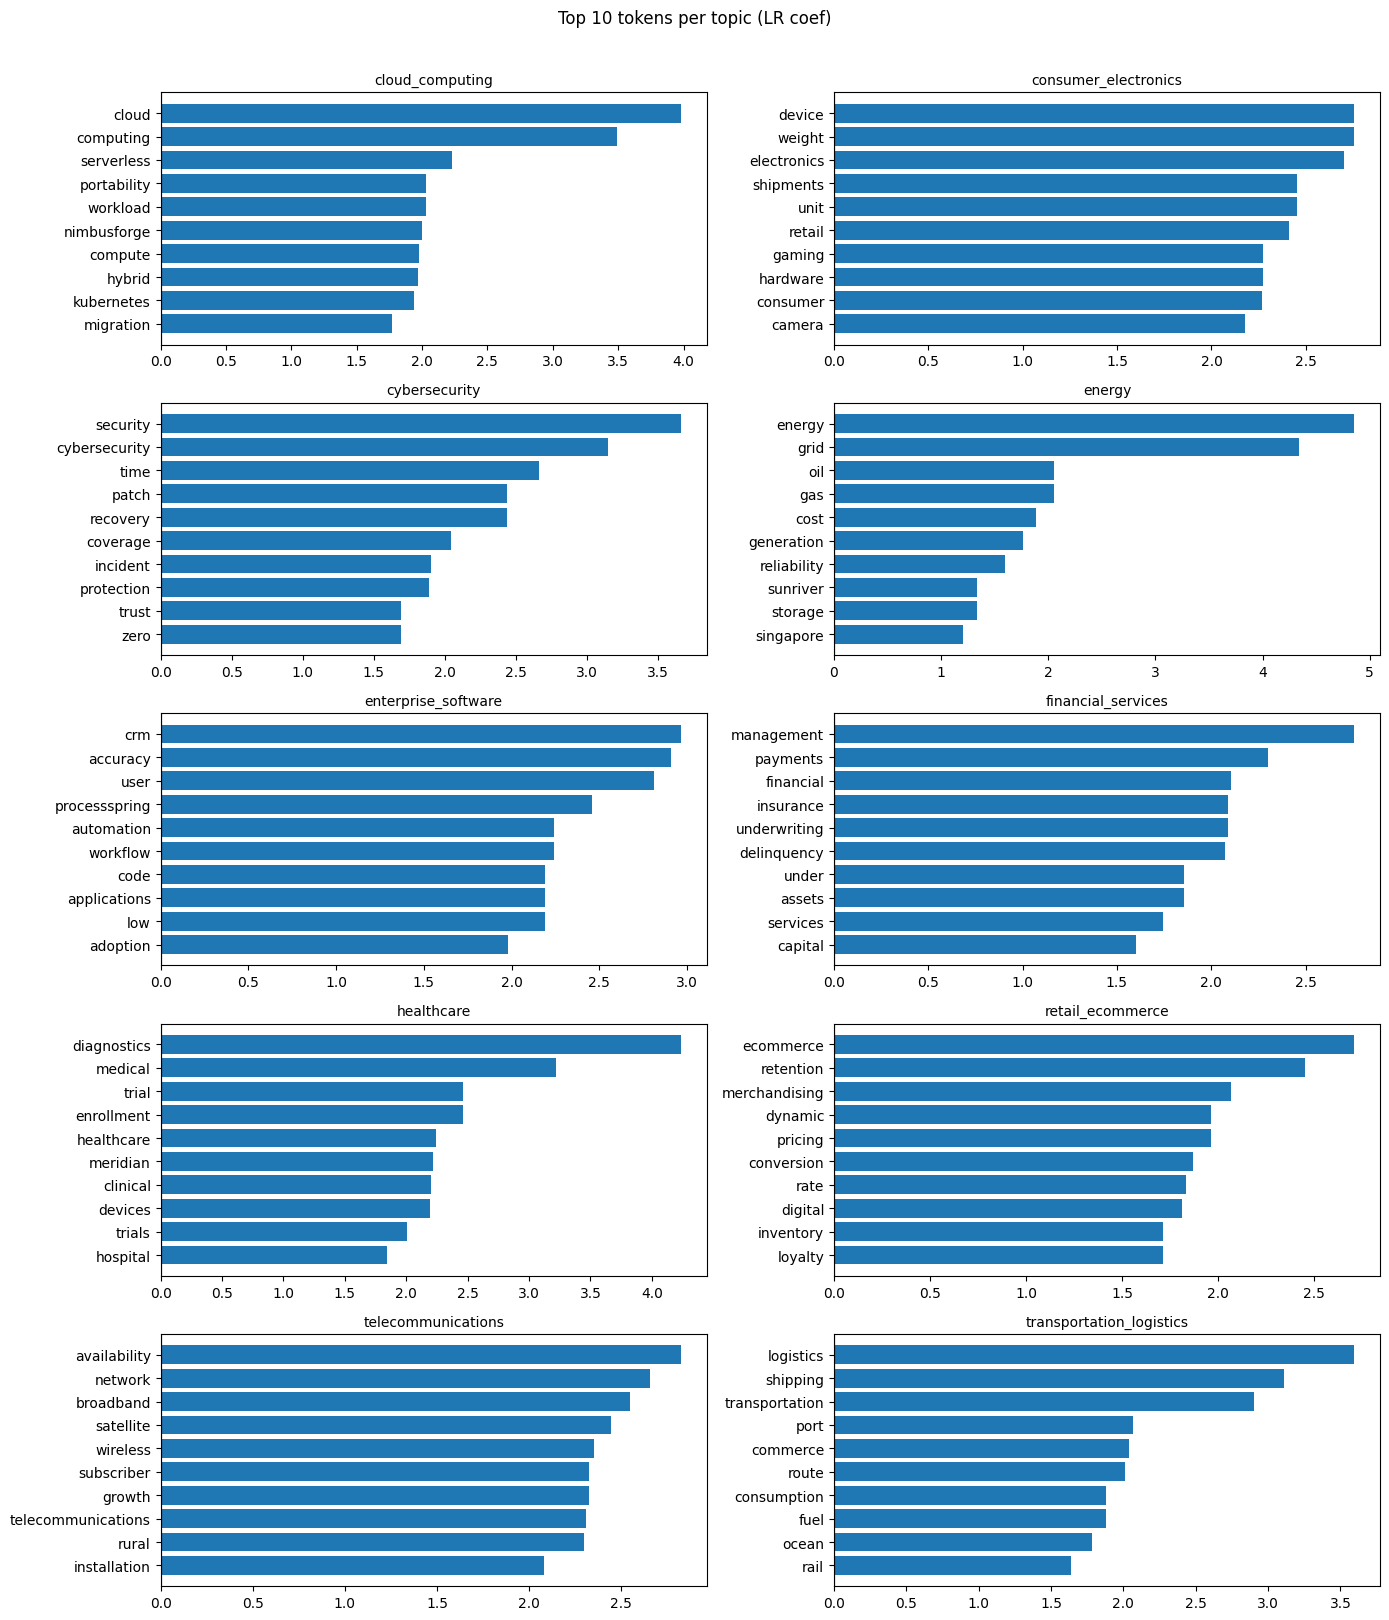

In [102]:
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_  # (n_classes, n_features)

TOP_N = 10
n_classes = len(CLASS_NAMES)
ncols = 2
nrows = int(np.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, cls, row in zip(axes, CLASS_NAMES, coefs):
    idx = np.argsort(row)[-TOP_N:]
    ax.barh(feature_names[idx], row[idx])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(cls, fontsize=10)

for ax in axes[n_classes:]:
    ax.axis("off")

fig.suptitle(f"Top {TOP_N} tokens per topic (LR coef)", y=1.01)
plt.tight_layout()
plt.show()


In [103]:
def local_token_contributions(text: str, class_name: str, top_k: int = 10) -> pd.DataFrame:
    class_idx = CLASS_NAMES.index(class_name)
    coefs_c = coefs[class_idx]
    x = tfidf.transform([text])
    contrib = np.asarray(x.multiply(coefs_c).todense()).ravel()
    nz = np.flatnonzero(x.toarray().ravel())
    order = nz[np.argsort(np.abs(contrib[nz]))[::-1][:top_k]]
    return pd.DataFrame({
        "token": feature_names[order],
        "tfidf": x.toarray().ravel()[order],
        "coef": coefs_c[order],
        "contribution": contrib[order],
    })


# Pick examples: 1 correct, 1 incorrect (if any)
test_index = X_test.index.to_numpy()
examples = []

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
p_pred = proba_test[np.arange(len(y_pred)), [class_to_idx[c] for c in y_pred]]
correct_idx = np.where(y_test.values == y_pred)[0]
incorrect_idx = np.where(y_test.values != y_pred)[0]

if len(correct_idx):
    best_correct = correct_idx[np.argmax(p_pred[correct_idx])]
    examples.append(("correct", int(best_correct)))
if len(incorrect_idx):
    best_incorrect = incorrect_idx[np.argmax(p_pred[incorrect_idx])]
    examples.append(("incorrect", int(best_incorrect)))

for label, i in examples:
    row_id = test_index[i]
    text = X_test.iloc[i]
    true_c = y_test.iloc[i]
    pred_c = y_pred[i]
    print("=" * 60)
    print(
        f"{label} | article_id={df.loc[row_id, 'article_id']} | "
        f"true={true_c} | pred={pred_c} | "
        f"P(pred)={proba_test[i, CLASS_NAMES.index(pred_c)]:.3f}"
    )
    print("title:", df.loc[row_id, "title"][:120])
    print(f"\nlocal contributions toward predicted class [{pred_c}]:")
    display(local_token_contributions(text, pred_c))
    if true_c != pred_c:
        print(f"\nlocal contributions toward true class [{true_c}]:")
        display(local_token_contributions(text, true_c))
    print()


correct | article_id=V4-0134 | true=consumer_electronics | pred=consumer_electronics | P(pred)=0.729
title: Arcadia Electronics Announces Multi-Year Battery Design Investment

local contributions toward predicted class [consumer_electronics]:


,token,tfidf,coef,contribution
0,electronics,0.226778,2.699609,0.612211
1,brightness,0.299031,1.347453,0.402931
2,screen,0.299031,1.347453,0.402931
3,consumer,0.127476,2.269766,0.289341
4,battery,0.176613,0.999979,0.176609
5,yet,0.102908,0.774191,0.079670
6,telecommunications,0.091620,0.737723,0.067591
7,hannah,0.137673,-0.468958,-0.064563
8,weiss,0.137673,-0.468958,-0.064563
9,links,0.115131,0.471407,0.054273



incorrect | article_id=V4-0180 | true=energy | pred=financial_services | P(pred)=0.876
title: The Market Debate Around Power Markets Has Changed

local contributions toward predicted class [financial_services]:


,token,tfidf,coef,contribution
0,markets,0.233440,1.411341,0.329463
1,debate,0.178817,1.451836,0.259613
2,over,0.178817,1.451836,0.259613
3,shifted,0.178817,1.451836,0.259613
4,should,0.178817,1.451836,0.259613
5,invest,0.178817,1.451836,0.259613
6,quickly,0.178817,1.451836,0.259613
7,produce,0.178817,1.451836,0.259613
8,measurable,0.164514,1.207825,0.198704
9,has,0.148680,0.767404,0.114098



local contributions toward true class [energy]:


,token,tfidf,coef,contribution
0,power,0.247743,1.187330,0.294153
1,modernization,0.104964,0.931790,0.097804
2,has,0.148680,-0.389348,-0.057888
3,are,0.129741,-0.387557,-0.050282
4,measurable,0.164514,-0.285602,-0.046985
5,as,0.090140,-0.470427,-0.042404
6,invest,0.178817,-0.215799,-0.038588
7,quickly,0.178817,-0.215799,-0.038588
8,shifted,0.178817,-0.215799,-0.038588
9,should,0.178817,-0.215799,-0.038588


## Save trained model

Saves the GridSearchCV-selected TF-IDF + multinomial LR pipeline.

Artifact → `models/ml_multi_v1.joblib` (next to `data/`).


In [105]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_multi_v1.joblib"

joblib.dump(best_model, MODEL_PATH)
print("saved:", MODEL_PATH.resolve())
print("reload example: loaded = joblib.load(MODEL_PATH)")


saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v1.joblib
reload example: loaded = joblib.load(MODEL_PATH)


## Notes / next steps

Broader roadmap beyond this TF-IDF + multinomial LR baseline (sequence by impact and risk).

### 1. Data & labels
- Grow data size; rare topics (n≈10) make holdout / CV / abstain slices noisy
- Label QA for topic guidelines; check synth template leakage
- Stress-test synth → real articles when real data is available
- Human-in-the-loop on abstains to feed new labeled data

### 2. Representations
- **TF-IDF (current)** → **pretrained text embeddings** with a frozen encoder + linear head
- Later: fine-tune an encoder if frozen embeddings plateau
- Side paths: char n-grams, hashing, SVD/NMF on TF-IDF

### 3. Features
- Add `title` and selected metadata with leakage checks
- Combine text + metadata in one pipeline

### 4. Models
- Classifier bake-off + hyperparameter tuning
- Prefer comparing a few diverse models fairly before stacking

### 5. Decisioning (Layer B)
- Current policy: **one global τ** on max-proba, chosen via **train OOF** probs for max routed macro-F1 subject to coverage ≥ 70% (fallback: best OOF F1 if no τ meets coverage)
- Margin (top1−top2) stays **diagnostic** here: same selection rule, but OOF coverage usually misses the 70% floor (small margins in 10-way softmax) — do not use as the operating policy
- Do not retune τ from test; freeze OOF-selected τ and report test once
- Later: coverage / quality floors as product knobs; per-class thresholds only with more data
- Product routing still maps predicted topic → Doc Center vs Quarantine; abstain = no auto-route

### 6. Evaluation
- Slice metrics (by length, difficulty, subtopic); learning curves
- Nested CV when tuning model + decision policy together
- Cost-sensitive / hierarchical topic metrics if product needs them

### 7. Explainability & error analysis
- Richer local explanations; embedding-appropriate methods later
- Confusion patterns across related topics (e.g. telecom vs cloud)
- Inspect abstains separately from Quarantine (manual review vs non-target auto-route)

### Out of scope until earlier steps pay off
- Per-class abstain thresholds on tiny n
- Full multi-model zoo on tiny n
- Heavy transformer fine-tuning before frozen embeddings
